# 06 — Baseline + XGBoost (target CMF_UVI)

- **การแบ่งข้อมูล** (`src/splits.py`): Train = 2023, **Dev = 2024** (ใช้เทียบโมเดลใน notebook นี้) ส่วน **Test = 2025 ไม่ได้โหลดเลย** เพราะ `load_model_data()` กรองปี 2025 ออกตั้งแต่ตอนอ่านไฟล์ จะใช้ครั้งเดียวในวัน 10
- **โมเดล** ถูกฝึกและบันทึกด้วย `python -m src.train_cmf` notebook นี้แค่โหลดโมเดลมาวิเคราะห์ผล
- **สเกล UVI:** UVI ที่ทำนาย = `uvi_clear` × CMF ที่ทำนาย (clip เป็น [0, 1]) แล้วเทียบกับ NASA POWER `nasa_uvi`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
import json

import joblib
from xgboost import XGBRegressor

from src.metrics import WHO_LEVELS_EN, regression_metrics, who_level_report
from src.splits import chronological_split, load_model_data
from src.train_cmf import MODEL_DIR, TARGET, load_spec, predict_cmf

features = load_spec()["features"]
train, dev = chronological_split(load_model_data())
print(f"train {len(train)} rows {train.time_utc.min().date()} -> {train.time_utc.max().date()}")
print(f"dev   {len(dev)} rows {dev.time_utc.min().date()} -> {dev.time_utc.max().date()}")

xgb = XGBRegressor(); xgb.load_model(MODEL_DIR / "cmf_xgb_v1.json")
linear = joblib.load(MODEL_DIR / "cmf_linear_v1.joblib")
dev = dev.assign(
    cmf_xgb=predict_cmf(xgb, dev[features]),
    cmf_lin=predict_cmf(linear, dev[features]),
)
dev["uvi_xgb"] = dev["uvi_clear"] * dev["cmf_xgb"]
dev["uvi_lin"] = dev["uvi_clear"] * dev["cmf_lin"]
dev["uvi_const"] = dev["uvi_clear"] * train[TARGET].mean()
table = pd.read_csv(ROOT / "docs" / "baseline_dev_2024.csv")
table.round(3)

train 3712 rows 2023-01-01 -> 2023-12-31
dev   3726 rows 2024-01-01 -> 2024-12-31


,model,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,cmf_mae,cmf_r2,who_accuracy,recall_Very high,recall_Extreme
0,constant CMF (train mean),0.703,0.998,0.889,-0.180,0.111,-0.004,0.760,0.631,0.000
1,Open-Meteo uv_index (no model),1.252,1.707,0.676,0.001,0.314,-10.084,0.613,0.591,0.000
2,linear regression,0.473,0.727,0.941,0.014,0.067,0.595,0.826,0.767,0.094
3,XGBoost,0.462,0.718,0.943,0.040,0.065,0.611,0.831,0.791,0.113


## 1. UVI ที่ทำนาย เทียบกับ NASA POWER (dev 2024)

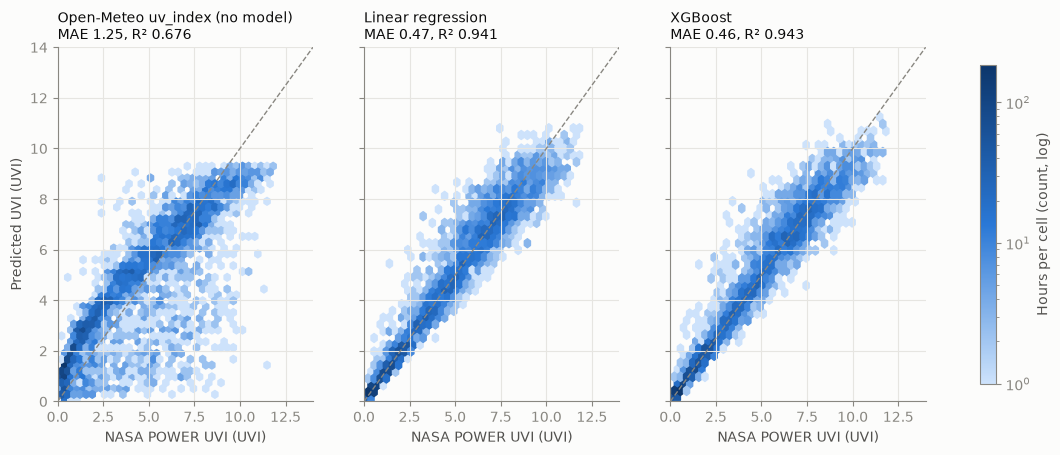

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharex=True, sharey=True)
lim = 14
for ax, col, color, name in [(axes[0], "uv_index", MUTED, "Open-Meteo uv_index (no model)"),
                             (axes[1], "uvi_lin", C_THIRD, "Linear regression"),
                             (axes[2], "uvi_xgb", C_OM, "XGBoost")]:
    m = regression_metrics(dev["nasa_uvi"], dev[col])
    hb = ax.hexbin(dev["nasa_uvi"], dev[col], gridsize=35, mincnt=1, bins="log",
              cmap=LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#0d366b"]))
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f"{name}\nMAE {m['mae']:.2f}, R² {m['r2']:.3f}", loc="left", fontsize=10)
    ax.set_xlabel("NASA POWER UVI (UVI)")
axes[0].set_ylabel("Predicted UVI (UVI)")
fig.colorbar(hb, ax=axes, shrink=0.9, label="Hours per cell (count, log)")
save(fig, "base_pred_vs_nasa_dev2024.png")

## 2. Error ตามชั่วโมง และ ตามเดือน (MAE บนสเกล UVI)

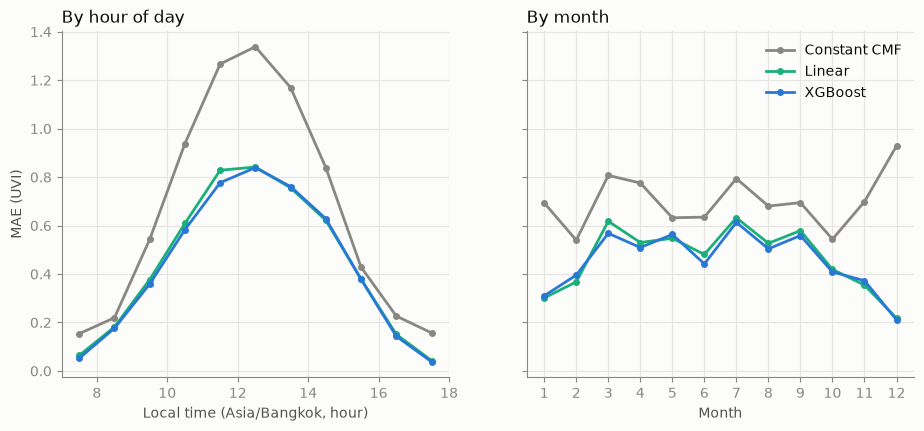

In [4]:
mid_local = (dev["time_utc"] - pd.Timedelta(minutes=30)).dt.tz_convert("Asia/Bangkok")
dev["hour_local"] = mid_local.dt.hour + 0.5
dev["month"] = mid_local.dt.month
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for col, color, name in [("uvi_const", MUTED, "Constant CMF"), ("uvi_lin", C_THIRD, "Linear"), ("uvi_xgb", C_OM, "XGBoost")]:
    err = (dev[col] - dev["nasa_uvi"]).abs()
    axes[0].plot(*zip(*err.groupby(dev["hour_local"]).mean().items()), color=color, marker="o", ms=4, label=name)
    axes[1].plot(*zip(*err.groupby(dev["month"]).mean().items()), color=color, marker="o", ms=4, label=name)
axes[0].set_xlabel("Local time (Asia/Bangkok, hour)"); axes[0].set_ylabel("MAE (UVI)")
axes[0].set_title("By hour of day", loc="left")
axes[1].set_xticks(range(1, 13)); axes[1].set_xlabel("Month")
axes[1].set_title("By month", loc="left"); axes[1].legend(loc="upper right")
save(fig, "base_error_hour_month.png")

## 3. Feature importance ของ XGBoost (gain)

direct_radiation         0.219
shortwave_radiation      0.146
hour_cos                 0.113
month_sin                0.070
om_kt                    0.067
aerosol_optical_depth    0.046
uv_index                 0.043
month_cos                0.038
om_diffuse_fraction      0.024
hour_sin                 0.023
dtype: float64

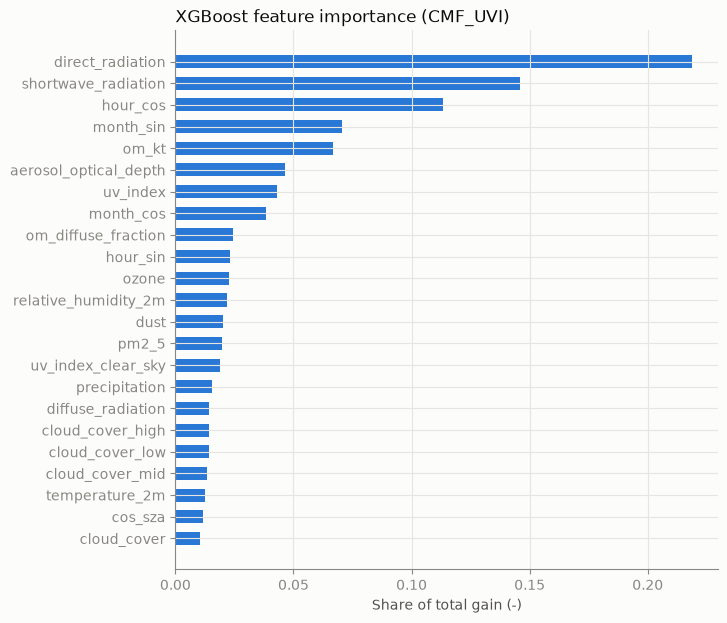

In [5]:
imp = pd.Series(json.loads((MODEL_DIR / "cmf_xgb_v1_metrics.json").read_text(encoding="utf-8"))["feature_importance_gain"])
imp = (imp / imp.sum()).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(imp.index, imp.values, color=C_OM, height=0.6)
ax.set_xlabel("Share of total gain (-)")
ax.set_title("XGBoost feature importance (CMF_UVI)", loc="left")
save(fig, "base_xgb_importance.png")
imp.sort_values(ascending=False).round(3).head(10)

## 4. ระดับ WHO: confusion matrix และ recall ของระดับ**สูงมาก**และ**รุนแรงมาก** (XGBoost, dev 2024)

            Low  Moderate  High  Very high  Extreme
Low        1228        48     1          0        0
Moderate     43       779   140         15        0
High          0        58   568        142        0
Very high     0         0   133        515        3
Extreme       0         0     0         47        6
{'Low': 0.962, 'Moderate': 0.797, 'High': 0.74, 'Very high': 0.791, 'Extreme': 0.113} accuracy 0.831


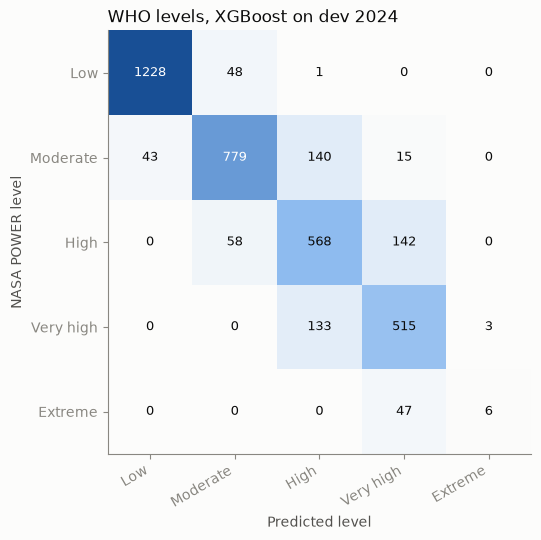

In [6]:
rep = who_level_report(dev["nasa_uvi"], dev["uvi_xgb"])
cm = rep["confusion"]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm.to_numpy(), cmap=LinearSegmentedColormap.from_list("seq", ["#fcfcfb", "#86b6ef", "#184f95"]))
ax.set_xticks(range(5), WHO_LEVELS_EN, rotation=30, ha="right"); ax.set_yticks(range(5), WHO_LEVELS_EN)
ax.grid(False)
for i in range(5):
    for j in range(5):
        v = cm.iloc[i, j]
        ax.text(j, i, v, ha="center", va="center", color="#ffffff" if v > cm.to_numpy().max() * 0.5 else INK, fontsize=9)
ax.set_xlabel("Predicted level"); ax.set_ylabel("NASA POWER level")
ax.set_title("WHO levels, XGBoost on dev 2024", loc="left")
save(fig, "base_who_confusion.png")
print(cm.to_string())
print({k: round(v, 3) for k, v in rep["recall"].items()}, "accuracy", round(rep["accuracy"], 3))

In [7]:
extreme = dev[dev["nasa_uvi"] >= 10.5]
print(f"Extreme hours in dev: {len(extreme)}; mean NASA {extreme.nasa_uvi.mean():.2f}, "
      f"mean XGB {extreme.uvi_xgb.mean():.2f}, mean uvi_clear {extreme.uvi_clear.mean():.2f}, "
      f"mean true CMF {extreme[TARGET].mean():.3f} vs predicted {extreme.cmf_xgb.mean():.3f}")

Extreme hours in dev: 53; mean NASA 10.98, mean XGB 9.65, mean uvi_clear 13.60, mean true CMF 0.808 vs predicted 0.709


## สรุป

1. **ผลบนสเกล UVI (dev 2024):** XGBoost ได้ MAE 0.46, RMSE 0.72, R² 0.943 ซึ่งผ่านเป้า Checkpoint วัน 10 (MAE < 1.0) แล้วบนชุด dev แต่ยังไม่ใช่ผล test ส่วน Linear regression ได้ใกล้กันมาก (MAE 0.47) แสดงว่าเมื่อมี physics (`uvi_clear`) เป็นตัวคูณอยู่แล้ว ส่วนที่เหลือเกือบเป็นเส้นตรง XGBoost ยังเหนือกว่าไม่มาก ซึ่งอาจดีขึ้นได้เมื่อ tune (วัน 8) และเมื่อฝึกด้วยข้อมูล 2 ปีในวัน 10
2. **Baseline:** CMF คงที่ (physics อย่างเดียว) ได้ MAE 0.70 แปลว่า ML ช่วยลด error ได้ ~34% ส่วนใช้ Open-Meteo `uv_index` ตรง ๆ แย่ที่สุด (MAE 1.25) เพราะค่าอิ่มตัวที่ ~9.3 ตรงกับที่พบในวัน 2
3. **Feature importance:** `direct_radiation`, `shortwave_radiation`, `hour_cos`, `month_sin` และ `om_kt` คือ feature ที่ใช้ได้ตอนใช้งานจริงเรื่องเมฆและรังสีจาก Open-Meteo รวมกับเวลา/ฤดู สอดคล้องกับ correlation ในวัน 5
4. **⚠️ ระดับรุนแรงมากถูกประเมินต่ำ:** recall ของระดับ**สูงมาก** 0.79 แต่ระดับ**รุนแรงมาก**แค่ 0.11 (จับได้ 6 จาก 53 ชั่วโมง) เพราะในชั่วโมงพวกนั้นโมเดลทำนาย CMF เฉลี่ย 0.71 ขณะที่ค่าจริงคือ 0.81 (regression to the mean ตอนฟ้าเปิดเที่ยงวัน) และทุกครั้งที่พลาดก็ตกลงไปแค่ระดับ**สูงมาก** ไม่มีครั้งไหนต่ำกว่านั้น ตาม rules การเตือนต้องใช้ **quantile บน (q90)** ซึ่งจะทำในวัน 9 และต้องตรวจ recall ของระดับรุนแรงมากอีกครั้งด้วยค่านั้น
5. **ยังไม่ได้แตะปี 2025:** ทุกตัวเลขข้างบนมาจาก dev 2024
